# Route One Agent Across Two Models

**One agent. One endpoint. Two model paths.**

```text
                              ┌──► routine model
agent ──► vllm-sr/auto ───────┤
                              └──► reasoning model
```

You will first experience routing, then use it through an agent, then
rebuild how it works and create a route for your own application.

By the end, you will be able to explain:

```text
requirement → signal → decision → priority → model → evidence
```


## 1. Start two models with vLLM

We will use:

| Model path | Job |
| --- | --- |
| Routine model | Direct, interactive, and lower-cost work |
| Reasoning model | Diagnosis, comparison, and multi-step work |

Open two Jupyter terminals.



Open the Jupyter launcher by clicking the **+** button:


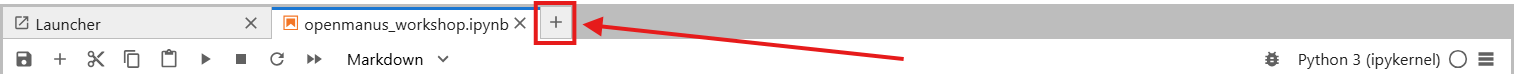


Choose **Terminal** from the launcher. Open two terminal tabs so each vLLM
server can stay in the foreground while you continue through the notebook.


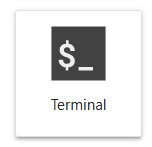


The workshop image already contains vLLM, the model cache, and the required
ROCm environment. In the first terminal, run the real vLLM command:

```bash
vllm serve google/gemma-4-12B-it \
  --host 0.0.0.0 \
  --port 8002 \
  --served-model-name gemma-4-12b \
  --gpu-memory-utilization 0.45 \
  --max-model-len 65536 \
  --kv-cache-dtype fp8 \
  --max-num-seqs 16 \
  --enable-auto-tool-choice \
  --tool-call-parser gemma4
```

In the second terminal:

```bash
vllm serve Qwen/Qwen3.8-27B-FP8 \
  --host 0.0.0.0 \
  --port 8001 \
  --served-model-name qwen3.8-27b \
  --gpu-memory-utilization 0.47 \
  --max-model-len 65536 \
  --kv-cache-dtype fp8 \
  --max-num-seqs 16 \
  --enforce-eager \
  --reasoning-parser qwen3 \
  --enable-auto-tool-choice \
  --tool-call-parser qwen3_xml
```

Notice the model, served-model name, port, tool parser, and GPU-memory
allocation. These are actual vLLM commands, not workshop wrappers.

Event-specific ROCm variables and model-cache paths are already configured in
the image's shell environment. Interested participants can inspect:

```text
/opt/workshop/config/environment.env
```

When both terminals report ready, run the next cell.


### Check the model servers

The next setup cell loads the workshop helper and checks the services. Its
implementation is hidden because environment discovery is provided by the
workshop image rather than being part of the routing lesson.


In [ ]:
import importlib
import workshop_lab

importlib.reload(workshop_lab)
lab = workshop_lab.lab
lab.welcome()
services = lab.status()


In [ ]:
models = lab.show_models()

if models["routine"] and models["reasoning"]:
    print("Both model servers are ready.")
else:
    print("Start the missing model server, then run this cell again.")


Generate one response from each model directly. At this point, vLLM-SR is not
involved. We are proving that each backend works before adding a Router.


In [ ]:
if models["routine"]:
    routine_backend_result = lab.direct_model_check("routine")
else:
    routine_backend_result = None
    print("Skipped until the routine model is running.")


In [ ]:
if models["reasoning"]:
    reasoning_backend_result = lab.direct_model_check("reasoning")
else:
    reasoning_backend_result = None
    print("Skipped until the reasoning model is running.")


## 2. Start the routing platform

Leave the two model terminals running. Router, Envoy, Dashboard, and their
supporting services are workshop plumbing, so start them from the next
notebook cell.

The cell returns immediately when the platform is already healthy. Otherwise,
it runs the inspectable `/opt/workshop/bin/start-platform.sh` script, waits
for startup, and prints a readiness summary.

You do not need another terminal for this step.


In [ ]:
services = lab.start_platform()


## 3. See routing before learning its configuration

Open the vLLM-SR Dashboard from this Jupyter session:


In [ ]:
lab.browser_links()


In **Dashboard → Playground**, select `vllm-sr/auto`.

First send:

> Give me a short definition of HTTP.

Record:

- selected decision;
- selected model; and
- latency.

Then send:

> Diagnose the likely causes of cascading failures in a distributed queue,
> compare three remedies, and justify a rollout plan.

Before sending the second prompt, predict whether it should use the same
model.

Open both requests in **Insights** and compare their route traces.


## 4. Prove that this is a normal application endpoint

Playground is useful for exploration, but applications use the ordinary
OpenAI-compatible API. Both requests below use:

```text
same endpoint: routed inference
same model:    vllm-sr/auto
```

Only the request changes.


In [ ]:
EASY_PROMPT = "Give me a short definition of HTTP."

if services["semantic router"]:
    easy_result = lab.routed_chat(EASY_PROMPT, max_tokens=80)
else:
    easy_result = None
    print("Skipped until the routed endpoint is running.")


In [ ]:
HARD_PROMPT = (
    "Diagnose the likely causes of cascading failures in a distributed "
    "queue, compare three remedies, and justify a rollout plan."
)

if services["semantic router"]:
    hard_result = lab.routed_chat(HARD_PROMPT, max_tokens=500)
else:
    hard_result = None
    print("Skipped until the routed endpoint is running.")


Compare:

| Prompt | Selected decision | Selected model |
| --- | --- | --- |
| Easy | Look at `easy_result` | Look at `easy_result` |
| Hard | Look at `hard_result` | Look at `hard_result` |

The key result is:

```text
same URL + same requested model + different request
= potentially different selected model
```


## 5. Give one task to an agent

Hermes is the preinstalled agent harness for this workshop. Its role is
simple:

> Turn one user task into several model requests and tool actions.

Hermes is already configured with:

```text
base URL: the vLLM-SR routed endpoint
model:    vllm-sr/auto
```

We will not study Hermes configuration or architecture.


In [ ]:
AGENT_TASK = (
    "Read this project and summarize what it does. Then solve this step "
    "by step: compare at least three safe ways to remove the duplicated "
    "pricing logic, explain their tradeoffs, choose the safest refactor, "
    "apply it, and run python -m pytest -q."
)

exercise_dir = lab.prepare_agent_demo()
print("Task Hermes will receive:")
print(AGENT_TASK)


The previous cell created a fresh working copy. The original fixture will not
be modified.

The next cell performs the complete demonstration:

1. record the request count for each model;
2. give the task to Hermes;
3. print progress while Hermes makes model and tool calls;
4. run the exercise tests;
5. record the model counts again; and
6. show how many requests reached each model.

Expect this to take a few minutes. It is a real agent loop, not a simulated
sequence.


In [ ]:
agent_run = lab.run_agent(AGENT_TASK, exercise_dir)


## Inspect the agent run in the Dashboard

1. Click **Open vLLM-SR Dashboard** above.
2. In the left navigation, select **Insights**.
3. Find the **Insight Records** section and the **Routing Insights** table.
4. Turn on **Auto-refresh**, or click **Refresh** once.
5. Look at the newest records created while the Hermes cell was running.
6. Compare the **Decision**, **Signals**, **Reasoning**, and
   **Model Change** columns.
7. Click a **Request ID** to open one request.
8. At the top of the record, follow:

   ```text
   requested model → selected decision → selected model
   ```

9. Inspect the message/tool trace below the routing details.

One Hermes task creates several Insight records because it produces several
inference requests.

You gave the agent **one task**, but the agent made several inference
requests:

```text
inspect → summarize → plan → edit → verify
```

Every request used `vllm-sr/auto`. Different requests could still select
different physical models.

vLLM-SR does not switch models halfway through one inference request. The
agent creates several requests, and the Router evaluates each one.


### Record what happened

Do not worry if your exact sequence differs. Agent runs produce real request
payloads, and the route should be evaluated from evidence rather than a
scripted promise.


In [ ]:
if agent_run.get("completed"):
    print("Task completed:", agent_run["completed"])
    print("Request deltas:", agent_run["delta"])
    print("Working copy:", agent_run["working_directory"])
else:
    print("Agent run was skipped:", agent_run.get("reason"))


## 6. Rebuild what you just observed

You have seen routing:

- visually in Playground;
- through the API; and
- inside a multi-turn agent task.

Now we will rebuild it from the smallest possible configuration.

We use separate configuration stages so the working demonstration route
remains available. The files will be written beside this notebook:

```text
route-one-agent-workshop/
└── generated-config/
    ├── 01-one-model.yaml
    ├── 02-two-models.yaml
    ├── 03-add-signal.yaml
    └── 04-add-decision.yaml
```

These are reviewable files, not hidden state. Creating or validating them
does **not** change the currently running Router.


### Stage 1 — One model, no routing choice

```text
application → vllm-sr/auto → routine-model
```

We need:

- one listener;
- one connected model;
- one model card;
- one public model name; and
- one match-all decision.


In [ ]:
from pathlib import Path
import subprocess
import yaml

NOTEBOOK_DIR = Path(workshop_lab.__file__).resolve().parent
CONFIG_DIR = NOTEBOOK_DIR / "generated-config"
CONFIG_DIR.mkdir(exist_ok=True)

def validate_config(path: Path) -> None:
    command = [lab.vllm_sr_bin, "validate", "--config", str(path)]
    print("$", " ".join(command))
    result = subprocess.run(
        command,
        check=False,
        capture_output=True,
        text=True,
    )
    print(result.stdout)
    if result.stderr:
        print(result.stderr)
    if result.returncode:
        raise RuntimeError(f"Configuration is invalid: {path}")


stage1_yaml = '''
version: v0.3

listeners:
  - name: workshop
    address: 0.0.0.0
    port: 8898
    timeout: 600s

providers:
  defaults:
    default_model: routine-model
  models:
    - name: routine-model
      api_format: openai
      provider_model_id: gemma-4-12b
      backend_refs:
        - name: routine-backend
          endpoint: 127.0.0.1:8002
          protocol: http
          type: vllm
          weight: 1

routing:
  modelCards:
    - name: routine-model
      modality: text
      context_window_size: 65536
  signals: {}
  decisions:
    - name: routine-lane
      description: Send every request to the routine model.
      priority: 100
      rules:
        operator: AND
        conditions: []
      modelRefs:
        - model: routine-model
      algorithm:
        type: static

global:
  router:
    auto_model_names:
      - vllm-sr/auto
  stores:
    response_cache:
      enabled: false
'''

stage1_path = CONFIG_DIR / "01-one-model.yaml"
stage1_path.write_text(stage1_yaml.strip() + "\n", encoding="utf-8")

print("Saved the complete one-model configuration to:")
print(stage1_path)
print()
print(stage1_path.read_text(encoding="utf-8"))
validate_config(stage1_path)


The empty `AND` condition is intentional:

```yaml
operator: AND
conditions: []
```

There is no condition that can fail, so this is the fallback that matches
every request.

`static` means the decision sends the request to its assigned model. With one
assigned model, there is nothing else to rank or coordinate.

The file is not active merely because it exists. In a standalone environment
you could run it with:

```bash
vllm-sr serve --config generated-config/01-one-model.yaml
```

In this workshop we leave the working demonstration route running and build
these files as understandable artifacts.


### Stage 2 — Connect the second model

```text
                                  ┌──► routine-model
application → vllm-sr/auto ───────┤
                                  └──► reasoning-model
```

We connect and describe the reasoning model, but do not change the policy.


In [ ]:
stage2 = yaml.safe_load(stage1_path.read_text(encoding="utf-8"))

reasoning_provider = {
    "name": "reasoning-model",
    "api_format": "openai",
    "provider_model_id": "qwen3.8-27b",
    "backend_refs": [
        {
            "name": "reasoning-backend",
            "endpoint": "127.0.0.1:8001",
            "protocol": "http",
            "type": "vllm",
            "weight": 1,
        }
    ],
}
reasoning_card = {
    "name": "reasoning-model",
    "modality": "text",
    "context_window_size": 65536,
}

stage2["providers"]["models"].append(reasoning_provider)
stage2["routing"]["modelCards"].append(reasoning_card)

stage2_path = CONFIG_DIR / "02-two-models.yaml"
stage2_path.write_text(
    yaml.safe_dump(stage2, sort_keys=False),
    encoding="utf-8",
)

print("Added these two objects:")
print(yaml.safe_dump(
    {
        "provider_model": reasoning_provider,
        "model_card": reasoning_card,
    },
    sort_keys=False,
))
print("Saved the complete configuration to:")
print(stage2_path)
validate_config(stage2_path)


Both prompts would still use the routine model.

> Connected does not mean eligible.

A decision must make the reasoning model eligible for a request.


### Stage 3 — Add an observation

Before making a choice, the Router needs something to observe.

A named observation is a **signal**. Our complexity signal can report:

```text
request_complexity:easy
request_complexity:medium
request_complexity:hard
```


In [ ]:
stage3 = yaml.safe_load(stage2_path.read_text(encoding="utf-8"))

complexity_signal = {
    "name": "request_complexity",
    "threshold": 0.10,
    "description": "Separate direct requests from reasoning-heavy work.",
    "hard": {
        "candidates": [
            "solve a multi-step problem",
            "compare competing designs and justify a choice",
            "diagnose a failure from incomplete evidence",
        ]
    },
    "easy": {
        "candidates": [
            "give a short definition",
            "summarize this briefly",
            "rewrite a sentence",
        ]
    },
}

stage3["routing"]["signals"]["complexity"] = [complexity_signal]

stage3_path = CONFIG_DIR / "03-add-signal.yaml"
stage3_path.write_text(
    yaml.safe_dump(stage3, sort_keys=False),
    encoding="utf-8",
)

print("Added this signal:")
print(yaml.safe_dump(
    {"complexity": [complexity_signal]},
    sort_keys=False,
))
print("Saved the complete configuration to:")
print(stage3_path)
validate_config(stage3_path)


Requests would still use the routine model.

> A signal observes. It does not select a model.

We still need a policy that acts on `request_complexity:hard`.


### Stage 4 — Add the decision

Our policy sentence:

```text
If complexity is hard, use the reasoning model.
Otherwise, use the routine model.
```


In [ ]:
stage4 = yaml.safe_load(stage3_path.read_text(encoding="utf-8"))

reasoning_decision = {
    "name": "reasoning-lane",
    "description": "Use the stronger model for difficult work.",
    "priority": 200,
    "rules": {
        "operator": "AND",
        "conditions": [
            {
                "type": "complexity",
                "name": "request_complexity:hard",
            }
        ],
    },
    "modelRefs": [
        {
            "model": "reasoning-model",
            "use_reasoning": True,
        }
    ],
    "algorithm": {"type": "static"},
}

stage4["routing"]["decisions"].insert(0, reasoning_decision)

stage4_path = CONFIG_DIR / "04-add-decision.yaml"
stage4_path.write_text(
    yaml.safe_dump(stage4, sort_keys=False),
    encoding="utf-8",
)

print("Added this higher-priority decision:")
print(yaml.safe_dump(reasoning_decision, sort_keys=False))
print("Saved the complete configuration to:")
print(stage4_path)
validate_config(stage4_path)


The progression:

| Stage | Easy prompt | Hard prompt |
| --- | --- | --- |
| One model | routine | routine |
| Second model connected | routine | routine |
| Complexity signal added | routine | routine |
| Reasoning decision added | routine | reasoning |

Now put names on what happened:

```text
signal      observed complexity
decision    turned hard into an eligible reasoning path
priority    selected the specific rule over the fallback
algorithm   executed the assigned model path
model       handled the request
```


## 7. Make the Router fit an application

Start with a requirement, not a Router feature:

> During an active production incident, acknowledgement speed is more
> important than deep analysis. Route incident-marked requests to the
> low-latency model, even when the request is otherwise complex.

Translate it:

```text
active incident
→ keyword signal
→ higher-priority decision
→ routine model
```


### Build the policy in the Dashboard

1. Click **Open vLLM-SR Dashboard**.
2. In the left navigation, open **Config Builder**.
3. Select the routing scope that contains `routine-lane` and
   `reasoning-lane`.
4. In **Signals**, add a **Keyword** signal named `active-incident`.
5. Add these case-insensitive phrases:
   - `SEV-1`
   - `production outage`
   - `service unavailable`
6. In **Routes**, add a route named `incident-fast-lane`.
7. Set its priority to `300`.
8. In **WHEN**, select the `active-incident` keyword signal.
9. In **THEN**, assign `routine-model` with the static algorithm.
10. Validate the draft before applying it.

Existing order:

```text
200  reasoning lane
100  routine fallback
```

New order:

```text
300  incident fast lane
200  reasoning lane
100  routine fallback
```

The next cell builds the same policy as a fifth reviewable YAML file. It does
not activate the file or overwrite the working Router.


In [ ]:
stage5 = yaml.safe_load(stage4_path.read_text(encoding="utf-8"))

incident_signal = {
    "name": "active-incident",
    "operator": "OR",
    "keywords": [
        "SEV-1",
        "production outage",
        "service unavailable",
    ],
    "case_sensitive": False,
}
incident_decision = {
    "name": "incident-fast-lane",
    "description": "Use the low-latency model during an active incident.",
    "priority": 300,
    "rules": {
        "operator": "AND",
        "conditions": [
            {
                "type": "keyword",
                "name": "active-incident",
            }
        ],
    },
    "modelRefs": [{"model": "routine-model"}],
    "algorithm": {"type": "static"},
}

stage5["routing"]["signals"]["keywords"] = [incident_signal]
stage5["routing"]["decisions"].insert(0, incident_decision)

stage5_path = CONFIG_DIR / "05-incident-policy.yaml"
stage5_path.write_text(
    yaml.safe_dump(stage5, sort_keys=False),
    encoding="utf-8",
)

print("Dashboard-equivalent signal:")
print(yaml.safe_dump(incident_signal, sort_keys=False))
print("Dashboard-equivalent decision:")
print(yaml.safe_dump(incident_decision, sort_keys=False))
print("Saved the complete configuration to:")
print(stage5_path)
validate_config(stage5_path)


### Predict before testing

> SEV-1 production outage. Diagnose the root cause, compare three remediation
> plans, and recommend a rollout.

It should match both the incident and hard-complexity policies. The incident
decision should win because it has the higher priority.

After applying the Dashboard draft:

1. Open **Playground**.
2. Select `vllm-sr/auto`.
3. Send the collision prompt.
4. Confirm that `incident-fast-lane` selected `routine-model`.
5. Open **Insights**.
6. Refresh **Routing Insights** and open the newest Request ID.
7. Confirm that both incident and complexity evidence were present, but
   priority `300` won.

Finally, repeat the same prompt through the API to prove that this behavior is
not limited to the Dashboard.


## 8. What you built is Mixture-of-Models

```text
one stable model identity
+ independently deployed models
+ policy choosing how a request is fulfilled
= Select-mode Mixture-of-Models
```

This differs from Mixture-of-Experts:

- MoE routes among internal experts inside one model.
- MoM coordinates separate model deployments.

Today you used **Select**: choose one model.

Workshop 2 begins here:

| Mode | What it adds |
| --- | --- |
| Cascade | Try one path and escalate |
| Fusion | Ask several models and synthesize |
| Workflow | Assign bounded planner, worker, and verifier roles |

In the next workshop, several models can participate in fulfilling one
inference request.


## 9. Your challenge

The guided incident rule showed the mechanics. Now design a route that
resembles your application.

Choose one:

- coding specialist;
- privacy/local-only boundary;
- long-context lane;
- medium-or-hard quality policy; or
- your own observable and testable requirement.

You must produce:

1. a one-sentence requirement;
2. the signal or signals;
3. the decision and model assignment;
4. its priority;
5. one positive test;
6. one negative test;
7. one collision test;
8. Playground or API evidence; and
9. an Insights trace explaining the winner.


In [ ]:
my_route = lab.incident_challenge_template()
my_route


Your route is complete when you can explain:

```text
requirement
→ observable evidence
→ signal
→ decision
→ priority
→ selected model
→ test evidence
```

Also answer:

- What would a false positive look like?
- What would a false negative look like?
- When the Router is uncertain, should your application favor cost, latency,
  privacy, or quality?


## Take-home result

You started with one model endpoint. You now know how to:

- keep one application-facing model name;
- connect several model paths;
- observe request meaning;
- express application policy;
- inspect and explain a routing decision;
- use the route through an agent; and
- design and test your own Select-mode Mixture-of-Models policy.

The next workshop moves from selecting one model to coordinating several.
